# PaSCient: supervised sample-level representations

[PaSCient](https://github.com/genentech/pascient) ([Rauer et al., 2024](https://arxiv.org/abs/2404.14413)) is a supervised deep learning method that learns patient-level representations from single-cell data. It uses a gene-to-cell encoder, attention-based cell-to-patient aggregation, and a patient encoder to produce fixed-size sample embeddings.

This notebook demonstrates how to use PaSCient through `patpy` on the COMBAT dataset.

## Setup

In [1]:
import pandas as pd
import scanpy as sc
import patpy
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

In [2]:
patpy.__version__

'0.14.0'

## Load and prepare data

We use the COMBAT dataset ([COMBAT Consortium, 2022](https://doi.org/10.1016/j.cell.2022.01.012)), available on [Kaggle](https://www.kaggle.com/datasets/vshitov/combat-covid-19-single-cell).

In [3]:
ADATA_PATH = "/home/icb/vladimir.shitov/projects/vladimir.shitov/2023_05_patient_representation_benchmark/reproducibility/pat_rep_benchmark/data/combat/combat_processed.h5ad"

In [4]:
adata = sc.read_h5ad(ADATA_PATH)
adata

AnnData object with n_obs × n_vars = 783677 × 3000
    obs: 'Annotation_cluster_id', 'Annotation_cluster_name', 'Annotation_minor_subset', 'Annotation_major_subset', 'Annotation_cell_type', 'GEX_region', 'QC_ngenes', 'QC_total_UMI', 'QC_pct_mitochondrial', 'QC_scrub_doublet_scores', 'TCR_chain_composition', 'TCR_clone_ID', 'TCR_clone_count', 'TCR_clone_proportion', 'TCR_contains_unproductive', 'TCR_doublet', 'TCR_chain_TRA', 'TCR_v_gene_TRA', 'TCR_d_gene_TRA', 'TCR_j_gene_TRA', 'TCR_c_gene_TRA', 'TCR_productive_TRA', 'TCR_cdr3_TRA', 'TCR_umis_TRA', 'TCR_chain_TRA2', 'TCR_v_gene_TRA2', 'TCR_d_gene_TRA2', 'TCR_j_gene_TRA2', 'TCR_c_gene_TRA2', 'TCR_productive_TRA2', 'TCR_cdr3_TRA2', 'TCR_umis_TRA2', 'TCR_chain_TRB', 'TCR_v_gene_TRB', 'TCR_d_gene_TRB', 'TCR_j_gene_TRB', 'TCR_c_gene_TRB', 'TCR_productive_TRB', 'TCR_chain_TRB2', 'TCR_v_gene_TRB2', 'TCR_d_gene_TRB2', 'TCR_j_gene_TRB2', 'TCR_c_gene_TRB2', 'TCR_productive_TRB2', 'TCR_cdr3_TRB2', 'TCR_umis_TRB2', 'BCR_umis_HC', 'BCR_contig_qc_HC

In [5]:
sample_id_col = "scRNASeq_sample_ID"
cell_type_key = "cell_type"
samples_metadata_cols = ["Source", "Outcome", "Death28", "Institute", "Pool_ID", "binary_condition"]

In [6]:
adata.obs.rename(columns={"Annotation_major_subset": cell_type_key}, inplace=True)

In [7]:
adata = adata[~adata.obs["Source"].isin(["Sepsis", "Flu"])]
adata.obs["binary_condition"] = adata.obs["Source"].str.contains("COVID").astype(int)
adata.obs["binary_condition"].value_counts()

/localscratch/vladimir.shitov/ipykernel_1408472/1289119485.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["binary_condition"] = adata.obs["Source"].str.contains("COVID").astype(int)


binary_condition
1    524530
0     87204
Name: count, dtype: int64

In [8]:
metadata = adata.obs[samples_metadata_cols + [sample_id_col]].drop_duplicates()
metadata.set_index(sample_id_col, inplace=True)
metadata

,Source,Outcome,Death28,Institute,Pool_ID,binary_condition
scRNASeq_sample_ID,,,,,,
S00109-Ja001E-PBCa,COVID_SEV,2.0,0,Oxford,gPlexA,1
S00112-Ja003E-PBCa,COVID_MILD,5.0,0,Oxford,gPlexA,1
S00005-Ja005E-PBCa,COVID_CRIT,2.0,0,Oxford,gPlexA,1
S00061-Ja003E-PBCa,COVID_SEV,4.0,0,Oxford,gPlexA,1
S00056-Ja003E-PBCa,COVID_SEV,3.0,0,Oxford,gPlexA,1
...,...,...,...,...,...,...
S00076-Ja001E-PBCa,COVID_MILD,5.0,0,Oxford,gPlexK,1
S00072-Ja001E-PBCa,COVID_SEV,2.0,0,Oxford,gPlexK,1
S00065-Ja003E-PBCa,COVID_CRIT,2.0,0,Oxford,gPlexK,1


In [9]:
adata = patpy.pp.filter_small_samples(adata, sample_key=sample_id_col, sample_size_threshold=250)

0 samples removed: 


## Train PaSCient

Initialize PaSCient with the default hyperparameters. We train from scratch on this dataset by passing `train=True` to `prepare_anndata`.

**Important:** PaSCient expects gene expression as input. You can either provide raw counts via the `layer` parameter (with `normalize=True`, the default, which applies log-normalization automatically), or provide already log-normalized data in `adata.X` (with `normalize=False`). Providing the correct expression input is critical for good performance.

In [10]:
pascient = patpy.tl.supervised.PaSCient(
    sample_key=sample_id_col,
    label_keys=["binary_condition"],
    tasks=["classification"],
    layer="X_raw_counts",
    normalize=True,
    n_cells=1500,
    batch_size=16,
    n_epochs=4,
    device="cuda",
)

In [11]:
pascient.prepare_anndata(adata, train=True)

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


/ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy/src/patpy/tl/supervised.py:1700: UserWarning: Using data from adata.layers['X_raw_counts']
  X = self._get_data()


/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'gene2cell_encoder' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['gene2cell_encoder'])`.
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'cell2cell_encoder' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['cell2cell_encoder'])`.
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'cell2patient_aggregation' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['cell2patient_aggregatio

GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


...

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/trainer/con
nectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. 
Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve 
performance.

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/d
ata.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 16. To avoid 
any miscalculations, use `self.log(..., batch_size=batch_size)`.

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/d
ata.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 11. To avoid 
any miscalculations, use `self.log(..., batch_size=batch_size)`.

`Trainer.fit` stopped: `max_epochs=4` reached.


/ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy/src/patpy/tl/supervised.py:1700: UserWarning: Using data from adata.layers['X_raw_counts']
  X = self._get_data()


## Sample representations

Extract sample-level embeddings and evaluate using the KNN prediction score.

In [12]:
pascient_sample_reps = pascient.get_sample_representations()
pascient_sample_reps

,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,dim_9,...,dim_502,dim_503,dim_504,dim_505,dim_506,dim_507,dim_508,dim_509,dim_510,dim_511
S00109-Ja001E-PBCa,-0.065178,0.272107,0.032048,-0.031076,-0.069556,-0.091724,0.161053,-0.046057,0.100335,0.298179,...,0.507783,0.552677,0.483049,-0.053666,-0.040912,-0.090007,0.147788,0.321822,-0.018591,0.261713
S00112-Ja003E-PBCa,-0.068158,0.262993,0.013541,-0.042150,-0.068785,-0.076845,0.085969,-0.062122,0.089794,0.353086,...,0.488915,0.543475,0.533868,-0.061865,-0.038743,-0.105146,0.137707,0.343619,-0.024020,0.251315
S00005-Ja005E-PBCa,-0.066516,0.266392,0.014560,-0.037347,-0.074442,-0.087228,0.102701,-0.069612,0.090872,0.379017,...,0.530959,0.571935,0.583567,-0.072983,-0.046853,-0.111577,0.161371,0.355576,-0.021059,0.243375
S00061-Ja003E-PBCa,-0.082544,0.313628,-0.001624,-0.039819,-0.081934,-0.089543,0.131824,-0.075782,0.094139,0.418272,...,0.614465,0.617850,0.588091,-0.068936,-0.056324,-0.128361,0.172850,0.391366,-0.011988,0.267577
S00056-Ja003E-PBCa,-0.064941,0.246303,0.000925,-0.046159,-0.069353,-0.084115,0.118129,-0.070042,0.091762,0.395472,...,0.541266,0.580656,0.585370,-0.072038,-0.044645,-0.112302,0.142444,0.349925,-0.023963,0.236203
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
S00076-Ja001E-PBCa,-0.055334,0.277672,0.055373,-0.036248,-0.054794,-0.067394,0.108679,-0.050157,0.070912,0.270890,...,0.441298,0.478458,0.471133,-0.050502,-0.032334,-0.088942,0.105130,0.296370,-0.025184,0.261764
S00072-Ja001E-PBCa,-0.066556,0.277785,0.105550,-0.033105,-0.056343,-0.067721,0.167154,-0.035103,0.110730,0.227117,...,0.430471,0.486647,0.400838,-0.029076,-0.035710,-0.068040,0.128550,0.256555,-0.016820,0.263547
S00065-Ja003E-PBCa,-0.061067,0.271121,0.056373,-0.039590,-0.056776,-0.071085,0.126489,-0.057418,0.091745,0.326453,...,0.514963,0.546035,0.499214,-0.056642,-0.039733,-0.091439,0.157885,0.330736,-0.026620,0.260555
S00048-Ja003E-PBCa,-0.062338,0.263495,0.036222,-0.029930,-0.067125,-0.079068,0.122315,-0.055446,0.109398,0.346706,...,0.496197,0.556562,0.502630,-0.060320,-0.042519,-0.094893,0.142488,0.313645,-0.027178,0.253804


In [13]:
pascient_distances = pascient.calculate_distance_matrix()
patpy.tl.evaluate_representation(
    pascient_distances,
    target=metadata.loc[pascient.samples, "binary_condition"],
    task="classification"
)

{'score': np.float64(0.889010989010989),
 'metric': 'f1_macro_calibrated',
 'n_unique': 2,
 'n_observations': 101,
 'method': 'knn'}

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


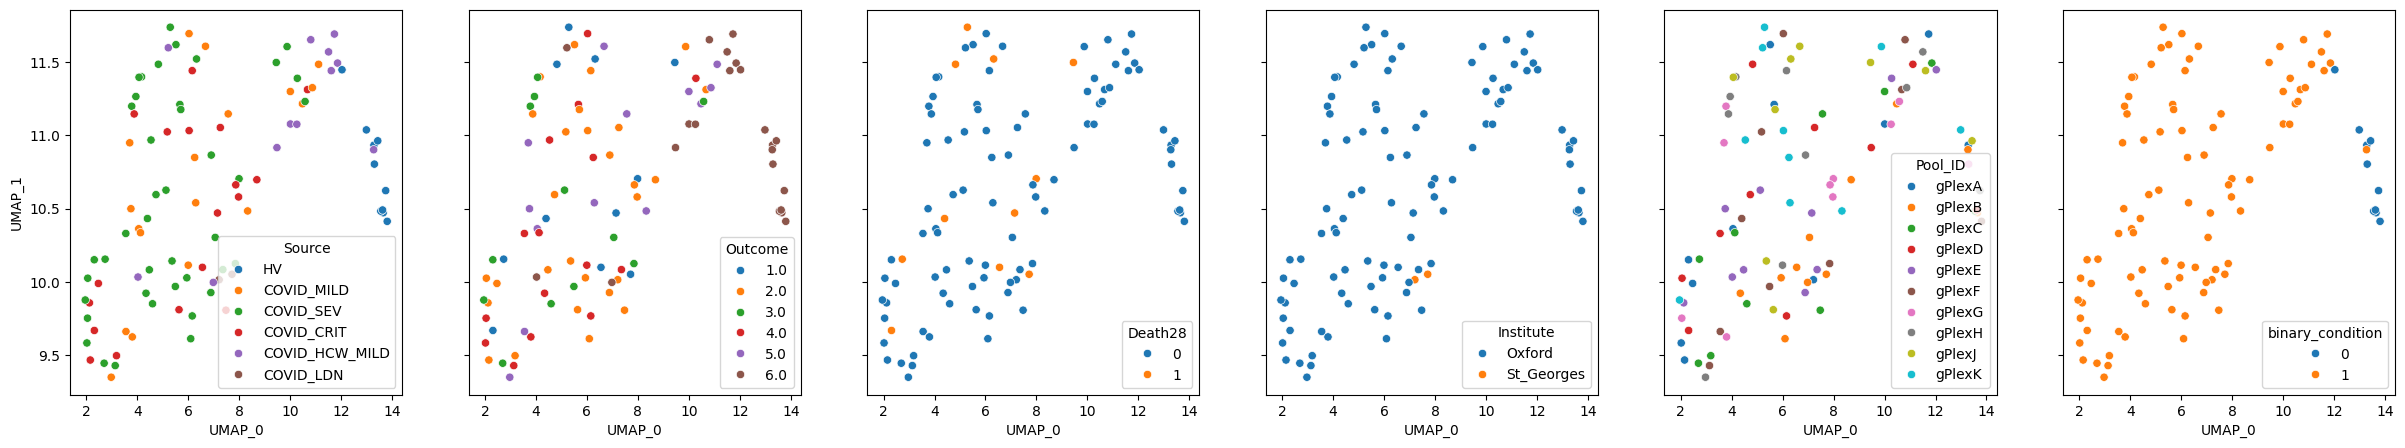

In [14]:
pascient.plot_embedding(method="UMAP", metadata_cols=samples_metadata_cols, continuous_palette="tab10");

## Binary prediction

Since `binary_condition` was specified as a label during training, PaSCient can predict it directly without additional fine-tuning.

In [15]:
pascient_prediction = pascient.predict("binary_condition")
pascient_prediction

/ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy/src/patpy/tl/supervised.py:1700: UserWarning: Using data from adata.layers['X_raw_counts']
  X = self._get_data()


,prob_0,prob_1,binary_condition_pred
S00109-Ja001E-PBCa,0.171956,0.828044,1
S00112-Ja003E-PBCa,0.166644,0.833356,1
S00005-Ja005E-PBCa,0.145273,0.854727,1
S00061-Ja003E-PBCa,0.117606,0.882394,1
S00056-Ja003E-PBCa,0.143293,0.856707,1
...,...,...,...
S00076-Ja001E-PBCa,0.211165,0.788835,1
S00072-Ja001E-PBCa,0.235127,0.764873,1
S00065-Ja003E-PBCa,0.177789,0.822211,1
S00048-Ja003E-PBCa,0.167064,0.832936,1


In [16]:
y_true = metadata.loc[pascient_prediction.index, "binary_condition"]
print(classification_report(y_true, pascient_prediction["binary_condition_pred"]))

              precision    recall  f1-score   support

           0       1.00      0.10      0.18        10
           1       0.91      1.00      0.95        91

    accuracy                           0.91       101
   macro avg       0.96      0.55      0.57       101
weighted avg       0.92      0.91      0.88       101



## Multiclass prediction

We can also fine-tune for the multiclass `Source` label.

In [17]:
metadata["Source"].value_counts()

Source
COVID_SEV         41
COVID_MILD        18
COVID_CRIT        18
COVID_HCW_MILD    12
HV                10
COVID_LDN          2
Name: count, dtype: int64

In [18]:
pascient.fine_tune("Source", tasks="classification")

/ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy/src/patpy/tl/supervised.py:1700: UserWarning: Using data from adata.layers['X_raw_counts']
  X = self._get_data()


GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/rich/live.py:260: 
UserWarning: install "ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/utilities/_
pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and 
treespec.is_leaf()` instead.

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/trainer/con
nectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider 
increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.

/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/lightning/pytorch/trainer/con
nectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. 
Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve 
performance.

`Trainer.fit` stopped: `max_epochs=4` reached.


In [19]:
pascient_source_prediction = pascient.predict("Source")
pascient_source_prediction

,prob_COVID_CRIT,prob_COVID_HCW_MILD,prob_COVID_LDN,prob_COVID_MILD,prob_COVID_SEV,prob_HV,Source_pred
S00109-Ja001E-PBCa,0.275497,0.089917,0.138762,0.217717,0.232781,0.045326,COVID_CRIT
S00112-Ja003E-PBCa,0.295172,0.079752,0.134997,0.212723,0.239901,0.037455,COVID_CRIT
S00005-Ja005E-PBCa,0.329372,0.066913,0.121670,0.201923,0.252520,0.027602,COVID_CRIT
S00061-Ja003E-PBCa,0.327011,0.063735,0.119137,0.216134,0.249394,0.024589,COVID_CRIT
S00056-Ja003E-PBCa,0.317062,0.072051,0.125732,0.206956,0.247932,0.030267,COVID_CRIT
...,...,...,...,...,...,...,...
S00076-Ja001E-PBCa,0.246973,0.106023,0.143852,0.227858,0.214718,0.060576,COVID_CRIT
S00072-Ja001E-PBCa,0.210900,0.123901,0.144720,0.232026,0.200046,0.088406,COVID_MILD
S00065-Ja003E-PBCa,0.301494,0.079014,0.129532,0.214855,0.238299,0.036807,COVID_CRIT
S00048-Ja003E-PBCa,0.305717,0.074125,0.128057,0.213353,0.245006,0.033742,COVID_CRIT


In [20]:
source_true = metadata.loc[pascient_source_prediction.index, "Source"]
print(classification_report(source_true, pascient_source_prediction["Source_pred"]))

                precision    recall  f1-score   support

    COVID_CRIT       0.24      0.94      0.38        18
COVID_HCW_MILD       0.00      0.00      0.00        12
     COVID_LDN       0.00      0.00      0.00         2
    COVID_MILD       0.30      0.33      0.32        18
     COVID_SEV       0.00      0.00      0.00        41
            HV       0.89      0.80      0.84        10

      accuracy                           0.31       101
     macro avg       0.24      0.35      0.26       101
  weighted avg       0.18      0.31      0.21       101



/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/icb/vladimir.shitov/software/miniconda3/envs/patpy/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to

### Cell importance

PaSCient can compute per-cell importance scores to identify which cells contribute most to sample-level representations.

> **Note:** By default, `get_cell_importance()` uses Integrated Gradients (IG) from the PaSCient paper when [captum](https://captum.ai/) is installed, and falls back to cosine similarity between cell and sample embeddings otherwise.

In [21]:
cell_importance = pascient.get_cell_importance(target=1)
importance_scores = cell_importance.iloc[:, 0]
print(f"Importance scores: min={importance_scores.min():.4f}, max={importance_scores.max():.4f}, mean={importance_scores.mean():.4f}")

/ictstr01/groups/luckylab/workspace/vladimir.shitov/patpy/src/patpy/tl/supervised.py:1700: UserWarning: Using data from adata.layers['X_raw_counts']
  X = self._get_data()


Importance scores: min=0.0000, max=0.0056, mean=0.0000


### Cell importance by disease severity and cell type

Visualize the distribution of cell importance scores. Since most scores are near zero with a long tail of important cells, we use strip plots with log-scaled y-axis for better visibility.

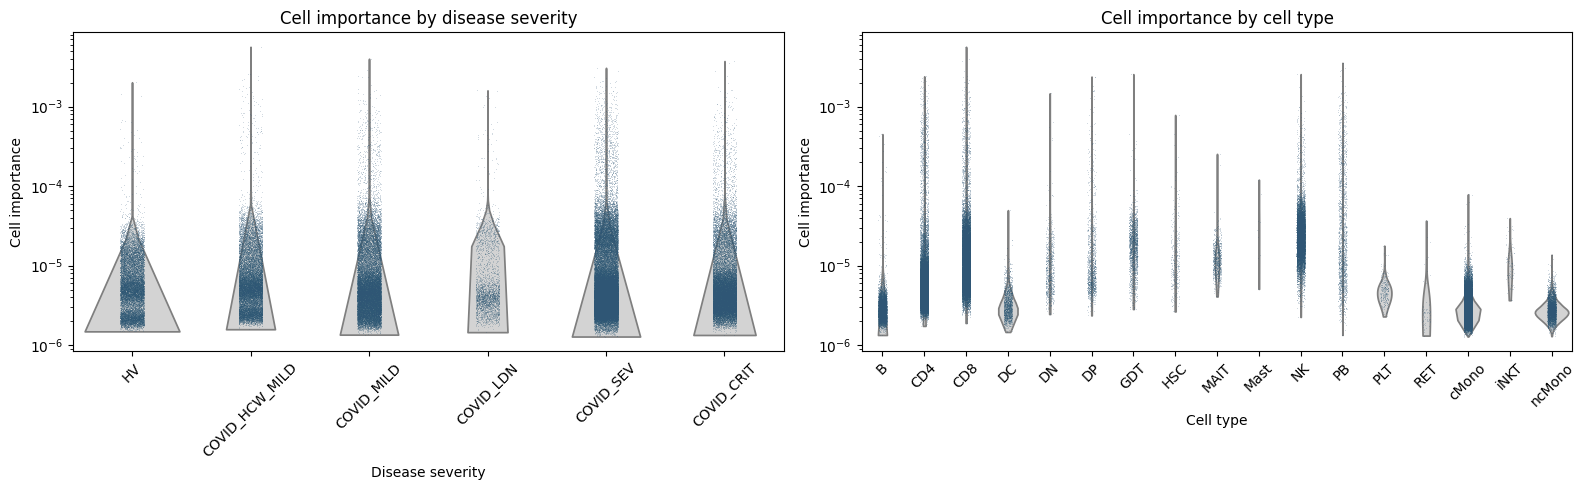

In [22]:
import seaborn as sns

# Build dataframe with importance scores and metadata
cell_imp_df = pd.DataFrame({
    "importance": importance_scores,
    "Source": adata.obs["Source"].values,
    "cell_type": adata.obs[cell_type_key].values,
}, index=adata.obs_names)

severity_order = ["HV", "COVID_HCW_MILD", "COVID_MILD", "COVID_LDN", "COVID_SEV", "COVID_CRIT"]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Filter to nonzero for log-scale strip plot
nonzero = cell_imp_df[cell_imp_df["importance"] > 0]

# By disease severity
ax = axes[0]
sns.violinplot(data=nonzero, x="Source", y="importance", order=severity_order,
               cut=0, inner=None, color="lightgrey", ax=ax)
sns.stripplot(data=nonzero, x="Source", y="importance", order=severity_order,
              size=0.5, alpha=0.3, jitter=True, ax=ax)
ax.set_yscale("log")
ax.set_xlabel("Disease severity")
ax.set_ylabel("Cell importance")
ax.set_title("Cell importance by disease severity")
ax.tick_params(axis="x", rotation=45)

# By cell type
ax = axes[1]
sns.violinplot(data=nonzero, x="cell_type", y="importance",
               cut=0, inner=None, color="lightgrey", ax=ax)
sns.stripplot(data=nonzero, x="cell_type", y="importance",
              size=0.5, alpha=0.3, jitter=True, ax=ax)
ax.set_yscale("log")
ax.set_xlabel("Cell type")
ax.set_ylabel("Cell importance")
ax.set_title("Cell importance by cell type")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Summary statistics

Descriptive statistics of cell importance scores grouped by disease severity and cell type.

In [23]:
print("=== Cell importance by disease severity ===")
cell_imp_df.groupby("Source")["importance"].describe().loc[severity_order].round(6)

=== Cell importance by disease severity ===


/localscratch/vladimir.shitov/ipykernel_1408472/745167923.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_imp_df.groupby("Source")["importance"].describe().loc[severity_order].round(6)


,count,mean,std,min,25%,50%,75%,max
Source,,,,,,,,
HV,87204.0,0.000001,0.000013,0.0,0.0,0.0,0.000000,0.002020
COVID_HCW_MILD,84359.0,0.000003,0.000038,0.0,0.0,0.0,0.000000,0.005638
COVID_MILD,107376.0,0.000004,0.000035,0.0,0.0,0.0,0.000002,0.003991
COVID_LDN,14832.0,0.000003,0.000033,0.0,0.0,0.0,0.000000,0.001599
COVID_SEV,230343.0,0.000004,0.000036,0.0,0.0,0.0,0.000002,0.003069
COVID_CRIT,87620.0,0.000004,0.000039,0.0,0.0,0.0,0.000003,0.003730


In [24]:
print("=== Cell importance by cell type ===")
cell_imp_df.groupby("cell_type")["importance"].describe().round(6)

=== Cell importance by cell type ===


/localscratch/vladimir.shitov/ipykernel_1408472/2882895137.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_imp_df.groupby("cell_type")["importance"].describe().round(6)


,count,mean,std,min,25%,50%,75%,max
cell_type,,,,,,,,
B,37103.0,0.000001,0.000005,0.0,0.0,0.0,0.000002,0.000450
CD4,218353.0,0.000003,0.000031,0.0,0.0,0.0,0.000000,0.002399
CD8,87562.0,0.000006,0.000054,0.0,0.0,0.0,0.000000,0.005638
DC,7287.0,0.000001,0.000002,0.0,0.0,0.0,0.000000,0.000050
DN,3426.0,0.000004,0.000031,0.0,0.0,0.0,0.000000,0.001468
DP,5354.0,0.000010,0.000084,0.0,0.0,0.0,0.000000,0.002380
GDT,7935.0,0.000006,0.000032,0.0,0.0,0.0,0.000000,0.002557
HSC,1124.0,0.000007,0.000033,0.0,0.0,0.0,0.000006,0.000784
MAIT,3977.0,0.000003,0.000008,0.0,0.0,0.0,0.000000,0.000254


In this tutorial you learned how to train PaSCient from scratch, extract sample representations, evaluate them, make binary and multiclass predictions, and compute cell importance scores with `patpy`.